In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile
import os

base_path = "/content/drive/MyDrive/"  # <-- change if needed

zip_files = [
    "HAM10000_images_part_1.zip",
    "HAM10000_images_part_2.zip"
]

output_folder = "/content/HAM10000_images/"

os.makedirs(output_folder, exist_ok=True)

for z in zip_files:
    print(f"Extracting {z}...")
    with zipfile.ZipFile(os.path.join(base_path, z), 'r') as zip_ref:
        zip_ref.extractall(output_folder)

print("Extraction complete!")


Extracting HAM10000_images_part_1.zip...
Extracting HAM10000_images_part_2.zip...
Extraction complete!


In [ ]:
import os

image_dir = "/content/HAM10000_images/"
print("Total images found:", len(os.listdir(image_dir)))


Total images found: 10015


Text(0.5, 1.0, 'Sample HAM10000 Image')

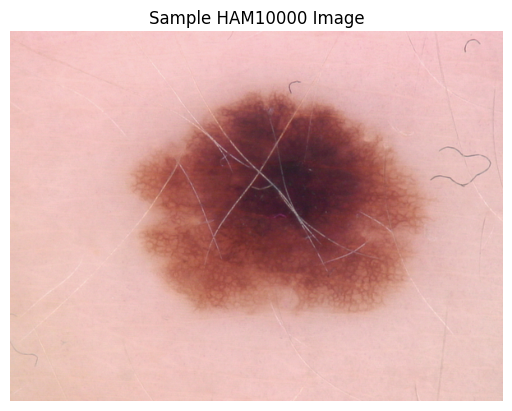

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

sample_image = os.path.join(image_dir, os.listdir(image_dir)[0])
img = mpimg.imread(sample_image)

plt.imshow(img)
plt.axis("off")
plt.title("Sample HAM10000 Image")


In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt


In [ ]:
IMAGE_DIR = "/content/HAM10000_images/"   # extracted folder
METADATA_PATH = "/content/drive/MyDrive/HAM10000_metadata.csv"

IMG_SIZE = 64   # change to 128 if needed


In [ ]:
df = pd.read_csv(METADATA_PATH, sep="\t", encoding="utf-8")


In [ ]:
print(df.columns)


Index(['lesion_id,image_id,dx,dx_type,age,sex,localization'], dtype='object')


In [ ]:
df.head()

,"lesion_id,image_id,dx,dx_type,age,sex,localization"
0,"HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,s..."
1,"HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,s..."
2,"HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,s..."
3,"HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,s..."
4,"HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear"


In [ ]:
df = pd.read_csv(METADATA_PATH, sep=None, engine="python")
print(df.columns)
df.head()


Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
print([repr(c) for c in df.columns])


["'lesion_id'", "'image_id'", "'dx'", "'dx_type'", "'age'", "'sex'", "'localization'"]


In [ ]:
IMAGE_DIR = "/content/HAM10000_images/"

df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGE_DIR, x + ".jpg"))


In [ ]:
print(df.columns)


Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'path'],
      dtype='object')


In [ ]:
print(df[['image_id', 'path']].head())


       image_id                                       path
0  ISIC_0027419  /content/HAM10000_images/ISIC_0027419.jpg
1  ISIC_0025030  /content/HAM10000_images/ISIC_0025030.jpg
2  ISIC_0026769  /content/HAM10000_images/ISIC_0026769.jpg
3  ISIC_0025661  /content/HAM10000_images/ISIC_0025661.jpg
4  ISIC_0031633  /content/HAM10000_images/ISIC_0031633.jpg


In [ ]:
import os
import pandas as pd

# Load metadata (already confirmed working)
METADATA_PATH = "/content/drive/MyDrive//HAM10000_metadata.csv"
df = pd.read_csv(METADATA_PATH)
df.columns = df.columns.str.strip()

print("Columns:", df.columns)

# Create path column
IMAGE_DIR = "/content/HAM10000_images/"
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGE_DIR, x + ".jpg"))

print(df[['image_id', 'path']].head())


Columns: Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')
       image_id                                       path
0  ISIC_0027419  /content/HAM10000_images/ISIC_0027419.jpg
1  ISIC_0025030  /content/HAM10000_images/ISIC_0025030.jpg
2  ISIC_0026769  /content/HAM10000_images/ISIC_0026769.jpg
3  ISIC_0025661  /content/HAM10000_images/ISIC_0025661.jpg
4  ISIC_0031633  /content/HAM10000_images/ISIC_0031633.jpg


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array

IMG_SIZE = 64  # recommended for DCGAN

def preprocess_image(path):
    img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    img = img_to_array(img)
    img = (img / 127.5) - 1.0   # normalize to [-1, 1]
    return img


In [ ]:
import numpy as np

all_images = []

for p in df['path']:
    all_images.append(preprocess_image(p))

all_images = np.array(all_images, dtype="float32")

print("Loaded shape:", all_images.shape)


Loaded shape: (10015, 64, 64, 3)


In [ ]:
BATCH_SIZE = 64
BUFFER_SIZE = 10000

dataset = tf.data.Dataset.from_tensor_slices(all_images)
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


Text(0.5, 1.0, 'Sample Preprocessed Image')

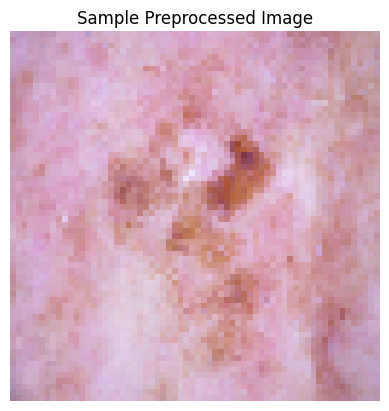

In [ ]:
import matplotlib.pyplot as plt

sample = (all_images[0] + 1) / 2.0  # convert back to [0,1]

plt.imshow(sample)
plt.axis("off")
plt.title("Sample Preprocessed Image")


# **StyleGAN2 Implementation for Data Augmentation**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import matplotlib.pyplot as plt
import numpy as np

LATENT_DIM = 100
IMG_SIZE = 64        # same as before
CHANNELS = 3
EPOCHS = 100         # you can increase later
BATCH_SIZE = 64
OUTPUT_DIR = "/content/gan_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [ ]:


# ---------- Mapping network (z -> w) ----------

def build_mapping_network(latent_dim=LATENT_DIM, dlatent_dim=256, num_layers=4):
    """
    Simple mapping network: z -> w
    """
    z_input = keras.Input(shape=(latent_dim,), name="z_input")

    # Normalize latent vector (as in StyleGAN)
    x = layers.Lambda(
        lambda z: z / (tf.sqrt(tf.reduce_mean(tf.square(z), axis=1, keepdims=True)) + 1e-8),
        name="latnorm"
    )(z_input)

    for i in range(num_layers):
        x = layers.Dense(dlatent_dim, activation="linear",
                         name=f"mapping_dense_{i}")(x)
        x = layers.LeakyReLU(0.2, name=f"mapping_lrelu_{i}")(x)

    return keras.Model(z_input, x, name="mapping_network")

# ---------- Style block helpers ----------

def adain(x, style, channels, name):
    """
    Adaptive Instance Normalization with style vector.
    x: feature map (N,H,W,C)
    style: w vector (N, dlatent_dim)
    """
    # style -> scale (gamma) and bias (beta)
    gamma = layers.Dense(channels, name=f"{name}_gamma")(style)
    beta = layers.Dense(channels, name=f"{name}_beta")(style)

    def _adain(inputs):
        feat, g, b = inputs
        mean, var = tf.nn.moments(feat, axes=[1, 2], keepdims=True)
        std = tf.sqrt(var + 1e-8)
        feat_norm = (feat - mean) / std

        g = tf.reshape(g, [-1, 1, 1, channels])
        b = tf.reshape(b, [-1, 1, 1, channels])
        return feat_norm * g + b

    return layers.Lambda(_adain, name=f"{name}_adain")([x, gamma, beta])

def style_block(x, style, filters, upsample, name):
    """
    One style block:
      optionally upsample -> conv -> AdaIN(style) -> LeakyReLU
    """
    if upsample:
        x = layers.UpSampling2D(interpolation="nearest",
                                name=f"{name}_upsample")(x)

    x = layers.Conv2D(filters, (3, 3), padding="same", use_bias=False,
                      name=f"{name}_conv")(x)
    x = adain(x, style, filters, name=f"{name}")
    x = layers.LeakyReLU(0.2, name=f"{name}_lrelu")(x)
    return x

# ---------- StyleGAN2-like generator ----------

def make_stylegan2_generator(
    latent_dim=LATENT_DIM,
    image_size=IMG_SIZE,
    channels=CHANNELS,
    dlatent_dim=256,
    base_filters=256
):
    """
    Lightweight StyleGAN2-inspired generator for 64x64 images.
    Not the official NVIDIA implementation, but captures the
    style-based idea (mapping network + style-modulated convs).
    """
    assert image_size == 64, "This example assumes 64x64 output."

    # Latent input
    z_input = keras.Input(shape=(latent_dim,), name="z")

    # Mapping network: z -> w
    mapping = build_mapping_network(latent_dim, dlatent_dim)
    w = mapping(z_input)   # (batch, dlatent_dim)

    # Start from a learned 4x4 feature map
    x = layers.Dense(4 * 4 * base_filters, name="dense_4x4")(w)
    x = layers.Reshape((4, 4, base_filters), name="reshape_4x4")(x)

    # 4x4 -> 8x8
    x = style_block(x, w, base_filters,     upsample=True, name="g_block_8")

    # 8x8 -> 16x16
    x = style_block(x, w, base_filters // 2, upsample=True, name="g_block_16")

    # 16x16 -> 32x32
    x = style_block(x, w, base_filters // 4, upsample=True, name="g_block_32")

    # 32x32 -> 64x64
    x = style_block(x, w, base_filters // 8, upsample=True, name="g_block_64")

    # Final RGB conv + tanh to match your DCGAN interface
    x = layers.Conv2D(
        channels,
        (1, 1),
        padding="same",
        activation="tanh",   # outputs in [-1, 1]
        name="g_rgb"
    )(x)

    return keras.Model(z_input, x, name="stylegan2_generator")


generator = make_stylegan2_generator(
    latent_dim=LATENT_DIM,
    image_size=IMG_SIZE,
    channels=CHANNELS,
    dlatent_dim=256,      # you can try 512 later
    base_filters=256      # can tune (128, 256, 512)
)

generator.summary()


Model: "stylegan2_generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ z (InputLayer)      │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mapping_network     │ (None, 256)       │    223,232 │ z[0][0]           │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4x4 (Dense)   │ (None, 4096)      │  1,052,672 │ mapping_network[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4x4         │ (None, 4, 4, 256) │          0 │ dense_4x4[0][0]   │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_block_8_upsample  │ (None, 8, 8, 256) │          0 │ reshape_4x4[0][0] │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_block_8_conv      │ (None, 8, 8, 256) │    589,824 │ g_block_8_upsamp… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_block_8_gamma     │ (None, 256)       │     65,792 │ mapping_network[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_block_8_beta      │ (None, 256)       │     65,792 │ mapping_network[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_block_8_adain     │ (None, 8, 8, 256) │          0 │ g_block_8_conv[0… │
│ (Lambda)            │                   │            │ g_block_8_gamma[… │
│                     │                   │            │ g_block_8_beta[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_block_8_lrelu     │ (None, 8, 8, 256) │          0 │ g_block_8_adain[… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_block_16_upsample │ (None, 16, 16,    │          0 │ g_block_8_lrelu[… │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_block_16_conv     │ (None, 16, 16,    │    294,912 │ g_block_16_upsam… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_block_16_gamma    │ (None, 128)       │     32,896 │ mapping_network[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_block_16_beta     │ (None, 128)       │     32,896 │ mapping_network[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_block_16_adain    │ (None, 16, 16,    │          0 │ g_block_16_conv[… │
│ (Lambda)            │ 128)              │            │ g_block_16_gamma… │
│                     │                   │            │ g_block_16_beta[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_block_16_lrelu    │ (None, 16, 16,    │          0 │ g_block_16_adain… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_block_32_upsample │ (None, 32, 32,    │          0 │ g_block_16_lrelu

 Total params: 2,499,619 (9.54 MB)

 Trainable params: 2,499,619 (9.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def make_discriminator_model():
    model = keras.Sequential(name="discriminator")

    # 64×64×3 → 32×32×64
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding="same",
                            input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS)))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    # 32×32×64 → 16×16×128
    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding="same"))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    # 16×16×128 → 8×8×256
    model.add(layers.Conv2D(256, (5, 5), strides=(2, 2), padding="same"))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    # Flatten to single probability (logit)
    model.add(layers.Flatten())
    model.add(layers.Dense(1))   # no activation (using from_logits=True)

    return model

discriminator = make_discriminator_model()
discriminator.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,045,633 (3.99 MB)

 Trainable params: 1,045,633 (3.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Binary cross-entropy loss for GANs
cross_entropy = keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    # Real images labeled as 1
    real_labels = tf.ones_like(real_output)
    real_loss = cross_entropy(real_labels, real_output)

    # Fake images labeled as 0
    fake_labels = tf.zeros_like(fake_output)
    fake_loss = cross_entropy(fake_labels, fake_output)

    return real_loss + fake_loss

def generator_loss(fake_output):
    # Generator wants fake_output to be classified as real (label=1)
    real_labels_for_fake = tf.ones_like(fake_output)
    return cross_entropy(real_labels_for_fake, fake_output)


In [ ]:
# Optimizers for generator and discriminator
generator_optimizer = keras.optimizers.Adam(1e-4, beta_1=0.5)
discriminator_optimizer = keras.optimizers.Adam(1e-4, beta_1=0.5)


In [ ]:
def generate_and_save_images(model, epoch, test_input, out_dir=OUTPUT_DIR,
                             num_rows=4, num_cols=4):
    # Generate images from the fixed seed
    predictions = model(test_input, training=False)

    # Convert from [-1, 1] back to [0, 1] for display/saving
    predictions = (predictions + 1.0) / 2.0
    predictions = tf.clip_by_value(predictions, 0.0, 1.0)

    fig = plt.figure(figsize=(num_cols * 2, num_rows * 2))

    for i in range(num_rows * num_cols):
        plt.subplot(num_rows, num_cols, i + 1)
        plt.imshow(predictions[i])
        plt.axis("off")

    # Save image grid
    save_path = os.path.join(out_dir, f"epoch_{epoch:03d}.png")
    plt.savefig(save_path)
    plt.close(fig)

    print(f"Saved sample grid to: {save_path}")


In [ ]:
# Number of images to generate for each saved grid
NUM_EXAMPLES_TO_GENERATE = 16

# Fixed noise input (latent vectors)
seed = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, LATENT_DIM])


In [ ]:
@tf.function
def train_step(real_images):
    batch_size = tf.shape(real_images)[0]

    # Sample random noise (latent vectors)
    noise = tf.random.normal([batch_size, LATENT_DIM])

    # Train both models together
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        # Generate fake images
        fake_images = generator(noise, training=True)

        # Discriminator predictions
        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(fake_images, training=True)

        # Compute losses
        g_loss = generator_loss(fake_output)
        d_loss = discriminator_loss(real_output, fake_output)

    # Calculate gradients
    gradients_of_generator = gen_tape.gradient(g_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(d_loss, discriminator.trainable_variables)

    # Apply gradients
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return g_loss, d_loss


In [ ]:
def train_stylegan(dataset, epochs):
    for epoch in range(1, epochs + 1):
        print(f"Epoch {epoch}/{epochs}")

        g_losses = []
        d_losses = []

        # Train on all batches in the dataset
        for real_batch in dataset:
            g_loss, d_loss = train_step(real_batch)
            g_losses.append(g_loss.numpy())
            d_losses.append(d_loss.numpy())

        # Print epoch losses
        print(f"  Generator loss:     {np.mean(g_losses):.4f}")
        print(f"  Discriminator loss: {np.mean(d_losses):.4f}")

        # Save generated image grid at key epochs
        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            generate_and_save_images(generator, epoch, seed)

    print("Training complete!")


In [ ]:
train_stylegan(dataset, EPOCHS)


Epoch 1/100
  Generator loss:     0.7905
  Discriminator loss: 1.3682
Saved sample grid to: /content/gan_outputs/epoch_001.png
Epoch 2/100
  Generator loss:     0.6849
  Discriminator loss: 1.3870
Epoch 3/100
  Generator loss:     0.7034
  Discriminator loss: 1.3749
Epoch 4/100
  Generator loss:     0.7151
  Discriminator loss: 1.3908
Epoch 5/100
  Generator loss:     0.6899
  Discriminator loss: 1.3779
Saved sample grid to: /content/gan_outputs/epoch_005.png
Epoch 6/100
  Generator loss:     0.7218
  Discriminator loss: 1.3642
Epoch 7/100
  Generator loss:     0.7215
  Discriminator loss: 1.3727
Epoch 8/100
  Generator loss:     0.7235
  Discriminator loss: 1.3712
Epoch 9/100
  Generator loss:     0.7242
  Discriminator loss: 1.3549
Epoch 10/100
  Generator loss:     0.7595
  Discriminator loss: 1.3344
Saved sample grid to: /content/gan_outputs/epoch_010.png
Epoch 11/100
  Generator loss:     0.7904
  Discriminator loss: 1.2943
Epoch 12/100
  Generator loss:     0.7450
  Discriminator

In [ ]:
import matplotlib.pyplot as plt

def show_generated_grid(epoch):
    img_path = f"/content/gan_outputs/epoch_{epoch:03d}.png"
    img = plt.imread(img_path)
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Generated Grid at Epoch {epoch}")
    plt.show()


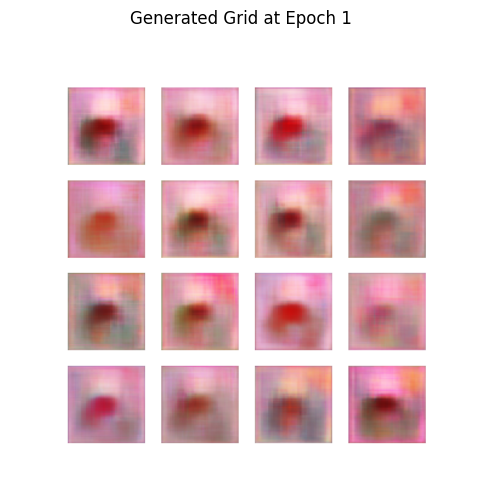

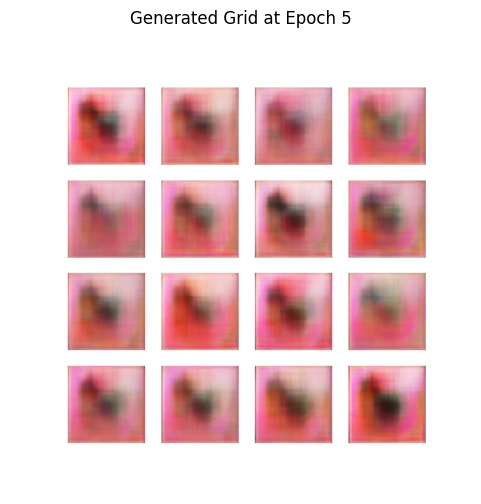

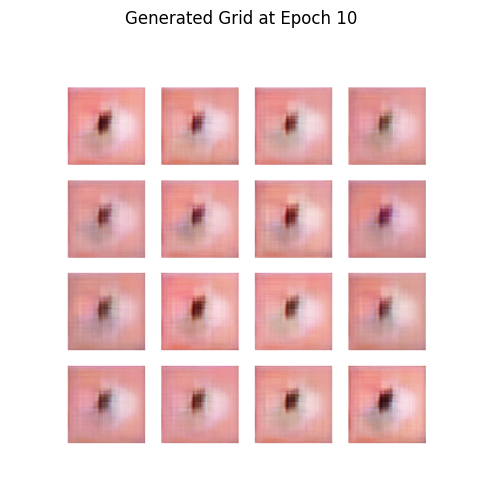

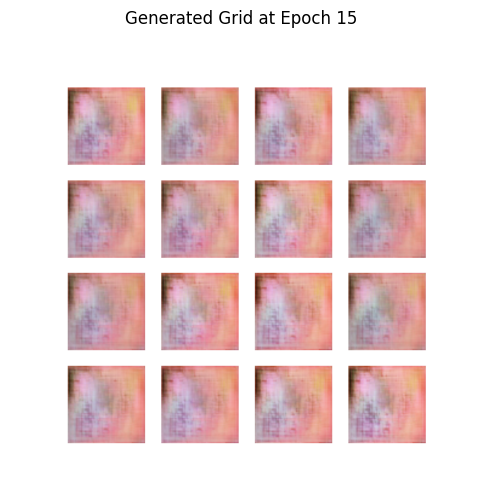

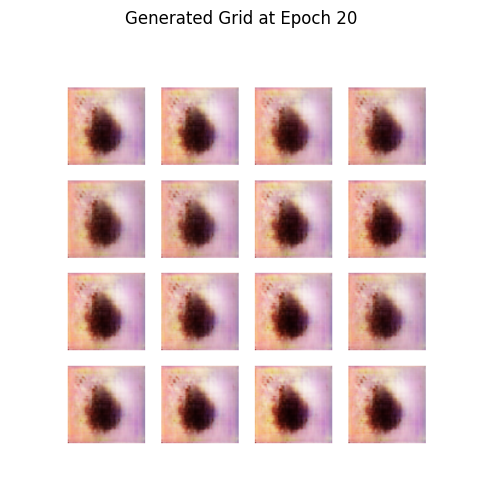

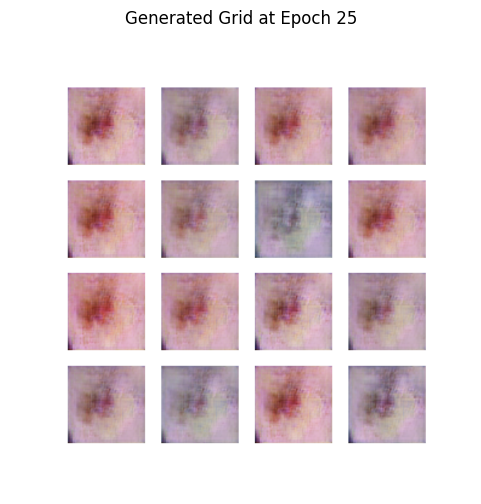

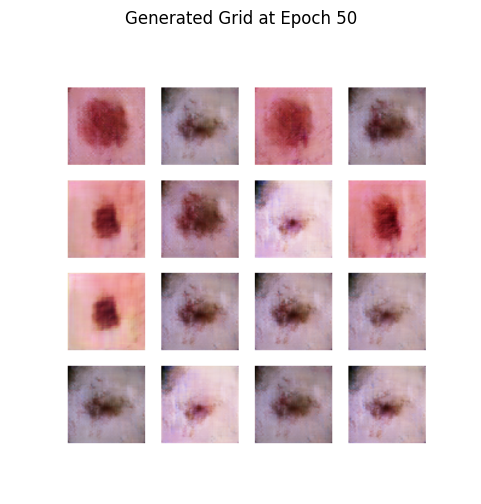

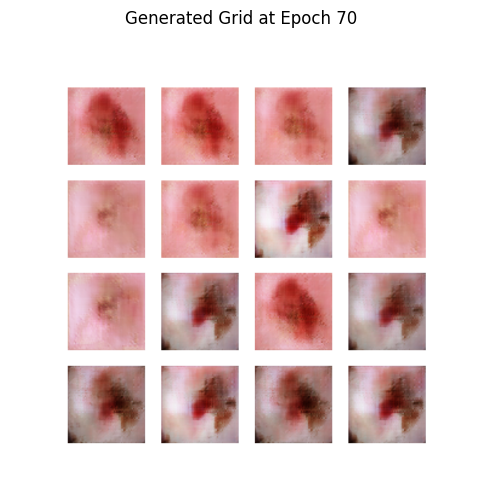

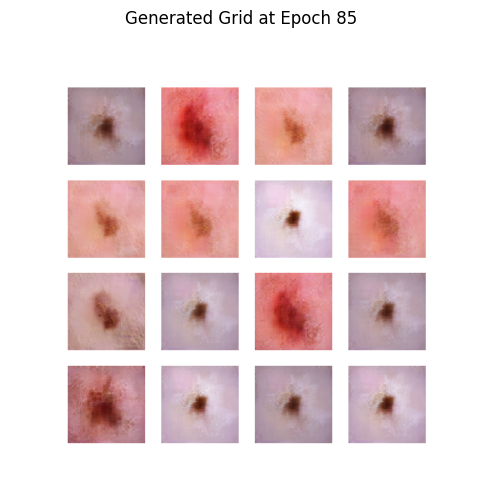

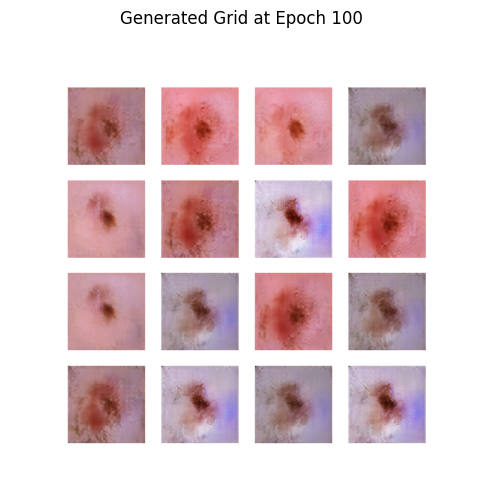

In [ ]:
show_generated_grid(1)
show_generated_grid(5)
show_generated_grid(10)
show_generated_grid(15)
show_generated_grid(20)
show_generated_grid(25)
show_generated_grid(50)
show_generated_grid(70)
show_generated_grid(85)
show_generated_grid(100)


In [ ]:
def generate_synthetic_images(num_images):
    noise = tf.random.normal([num_images, LATENT_DIM])
    fake_images = generator(noise, training=False)
    fake_images = (fake_images + 1.0) / 2.0  # [-1,1] -> [0,1]
    fake_images = tf.clip_by_value(fake_images, 0.0, 1.0)
    return fake_images.numpy()


In [ ]:
tf.random.set_seed(42)
synthetic_images = generate_synthetic_images(2000)
print(synthetic_images.shape)


(2000, 64, 64, 3)


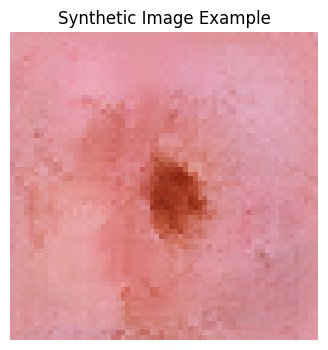

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
plt.imshow(synthetic_images[1000])
plt.axis("off")
plt.title("Synthetic Image Example")
plt.show()


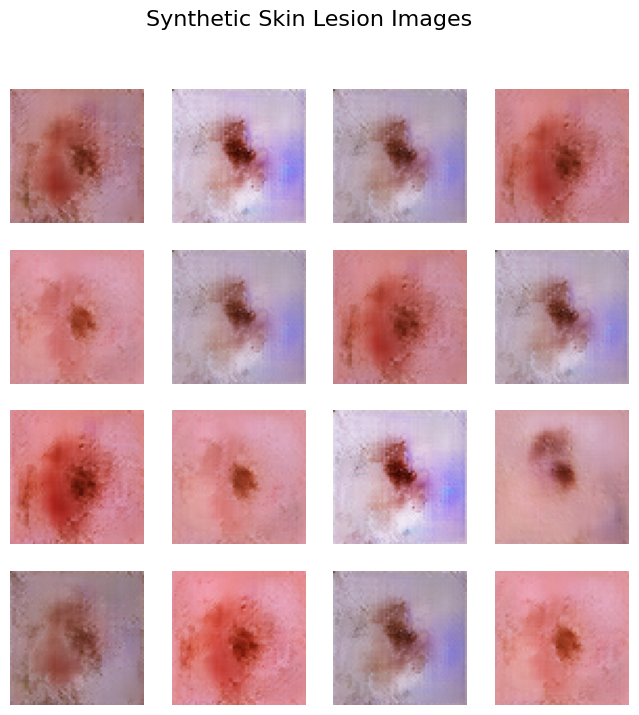

In [ ]:
def show_synthetic_grid(images, rows=4, cols=4):
    plt.figure(figsize=(cols * 2, rows * 2))

    for i in range(rows * cols):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i])
        plt.axis("off")

    plt.suptitle("Synthetic Skin Lesion Images", fontsize=16)
    plt.show()

# Display a 4x4 grid
show_synthetic_grid(synthetic_images, rows=4, cols=4)


In [ ]:
import numpy as np

majority_class = df['dx'].value_counts().idxmax()
majority_class


'nv'

In [ ]:
label_names = sorted(df['dx'].unique())
label_to_idx = {name: i for i, name in enumerate(label_names)}

label_to_idx


{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}

In [ ]:
synthetic_label_idx = label_to_idx[majority_class]
synthetic_label_idx


5

In [ ]:
num_synthetic = synthetic_images.shape[0]
synthetic_labels = np.full(num_synthetic, synthetic_label_idx)
synthetic_labels.shape


(2000,)

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def prepare_classifier_images(df):
    X, y = [], []

    for _, row in df.iterrows():
        # Load image resized to IMG_SIZE × IMG_SIZE
        img = load_img(row["path"], target_size=(IMG_SIZE, IMG_SIZE))

        # Convert to numpy array
        img = img_to_array(img)

        # Normalize to [0,1] for CNN
        img = img / 255.0

        X.append(img)
        y.append(row["dx"])   # label (string)

    return np.array(X, dtype="float32"), np.array(y)


In [ ]:
X_real, y_real_labels = prepare_classifier_images(df)
print(X_real.shape, y_real_labels.shape)


(10015, 64, 64, 3) (10015,)


In [ ]:
label_names = sorted(df['dx'].unique())
label_to_idx = {name: i for i, name in enumerate(label_names)}

y_real = np.array([label_to_idx[label] for label in y_real_labels])
print(label_to_idx)


{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_real, y_real,
    test_size=0.30,
    stratify=y_real,
    random_state=42
)


In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)


In [ ]:
print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)


(7010, 64, 64, 3) (1502, 64, 64, 3) (1503, 64, 64, 3)
(7010,) (1502,) (1503,)


## **CNN Classifier on Raw + StyleGAN2 Augmented Data**

In [ ]:
from tensorflow.keras.utils import to_categorical

num_classes = len(label_names)

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)


In [ ]:
from tensorflow.keras import layers, Model, Input

def make_cnn_classifier(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=7):
    inputs = Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D()(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    # Dense layers
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [ ]:
baseline_cnn = make_cnn_classifier()
baseline_cnn.summary()


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,855 (4.36 MB)

 Trainable params: 1,142,855 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_baseline = baseline_cnn.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=75,
    batch_size=32
)


Epoch 1/75
220/220 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.6530 - loss: 1.2073 - val_accuracy: 0.6698 - val_loss: 0.9797
Epoch 2/75
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6697 - loss: 0.9934 - val_accuracy: 0.6684 - val_loss: 0.9207
Epoch 3/75
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6717 - loss: 0.9406 - val_accuracy: 0.6718 - val_loss: 0.8872
Epoch 4/75
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6740 - loss: 0.9105 - val_accuracy: 0.6844 - val_loss: 0.8629
Epoch 5/75
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6782 - loss: 0.8899 - val_accuracy: 0.6884 - val_loss: 0.8550
Epoch 6/75
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6846 - loss: 0.8710 - val_accuracy: 0.6931 - val_loss: 0.8360
Epoch 7/75
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6889 - loss: 0.8570 - val_accuracy: 0.6997 - val_loss: 0.8219
Epoch 8/75
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6949 - loss: 0.8429 - val_accuracy: 

In [ ]:
baseline_loss, baseline_acc = baseline_cnn.evaluate(X_test, y_test_cat)
print("Baseline Test Accuracy:", baseline_acc)
print("Baseline Test Loss:", baseline_loss)


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7677 - loss: 0.7468
Baseline Test Accuracy: 0.7684630751609802
Baseline Test Loss: 0.7611424922943115


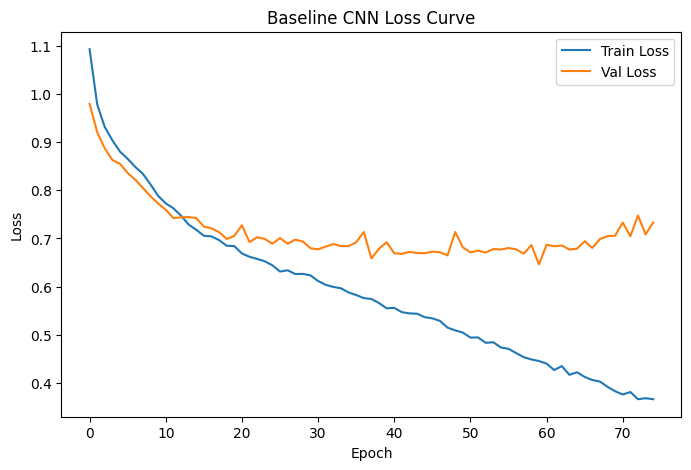

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Val Loss')
plt.title("Baseline CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


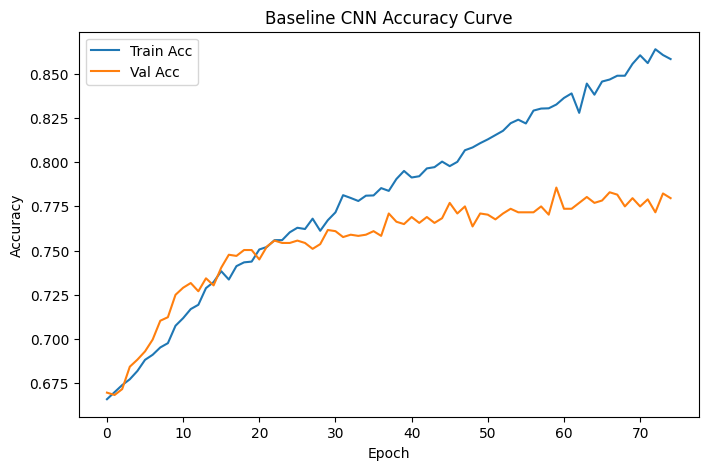

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_baseline.history['accuracy'], label='Train Acc')
plt.plot(history_baseline.history['val_accuracy'], label='Val Acc')
plt.title("Baseline CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [ ]:
y_pred_probs = baseline_cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


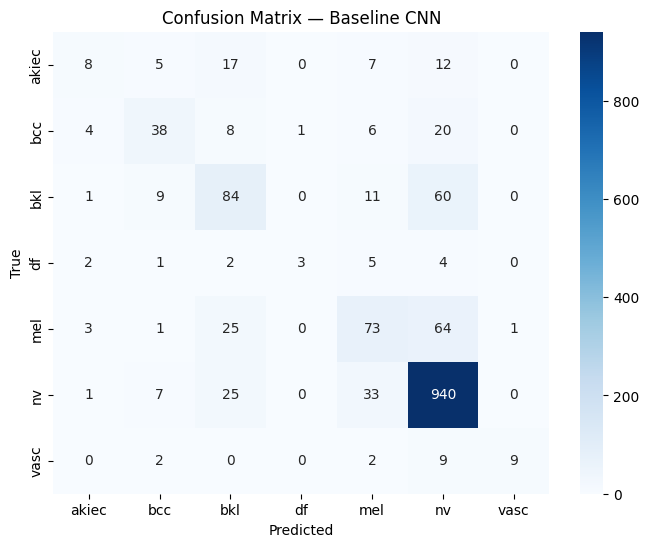

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=label_names,
            yticklabels=label_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Baseline CNN")
plt.show()


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=label_names))

              precision    recall  f1-score   support

       akiec       0.42      0.16      0.24        49
         bcc       0.60      0.49      0.54        77
         bkl       0.52      0.51      0.52       165
          df       0.75      0.18      0.29        17
         mel       0.53      0.44      0.48       167
          nv       0.85      0.93      0.89      1006
        vasc       0.90      0.41      0.56        22

    accuracy                           0.77      1503
   macro avg       0.65      0.45      0.50      1503
weighted avg       0.75      0.77      0.75      1503



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

micro_precision = precision_score(y_true, y_pred, average='micro')
macro_precision = precision_score(y_true, y_pred, average='macro')

micro_recall = recall_score(y_true, y_pred, average='micro')
macro_recall = recall_score(y_true, y_pred, average='macro')

micro_f1 = f1_score(y_true, y_pred, average='micro')
macro_f1 = f1_score(y_true, y_pred, average='macro')

test_accuracy = accuracy_score(y_true, y_pred)

print("Micro Precision:", micro_precision)
print("Macro Precision:", macro_precision)
print("Micro Recall:", micro_recall)
print("Macro Recall:", macro_recall)
print("Micro F1:", micro_f1)
print("Macro F1:", macro_f1)
print("Test Accuracy:", test_accuracy)


Micro Precision: 0.7684630738522954
Macro Precision: 0.6537747914843658
Micro Recall: 0.7684630738522954
Macro Recall: 0.4461347989600033
Micro F1: 0.7684630738522954
Macro F1: 0.501550716616428
Test Accuracy: 0.7684630738522954


In [ ]:
X_aug = np.concatenate([X_train, synthetic_images], axis=0)
X_aug.shape


(9010, 64, 64, 3)

In [ ]:
y_aug = np.concatenate([y_train, synthetic_labels], axis=0)
y_aug.shape


(9010,)

In [ ]:
from tensorflow.keras.utils import to_categorical

y_aug_cat = to_categorical(y_aug, num_classes)
y_aug_cat.shape


(9010, 7)

In [ ]:
aug_cnn = make_cnn_classifier()   # same function used earlier
aug_cnn.summary()


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,855 (4.36 MB)

 Trainable params: 1,142,855 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_aug = aug_cnn.fit(
    X_aug, y_aug_cat,
    validation_data=(X_val, y_val_cat),
    epochs=60,
    batch_size=32
)


Epoch 1/60
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7260 - loss: 1.0715 - val_accuracy: 0.6698 - val_loss: 0.9842
Epoch 2/60
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7426 - loss: 0.8240 - val_accuracy: 0.6718 - val_loss: 0.9259
Epoch 3/60
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7460 - loss: 0.7469 - val_accuracy: 0.6731 - val_loss: 0.8934
Epoch 4/60
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7503 - loss: 0.7183 - val_accuracy: 0.6831 - val_loss: 0.8624
Epoch 5/60
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7512 - loss: 0.6964 - val_accuracy: 0.6937 - val_loss: 0.8463
Epoch 6/60
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7550 - loss: 0.6822 - val_accuracy: 0.6924 - val_loss: 0.8294
Epoch 7/60
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7575 - loss: 0.6577 - val_accuracy: 0.6891 - val_loss: 0.8178
Epoch 8/60
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7619 - loss: 0.6405 - val_accuracy: 0

In [ ]:
aug_loss, aug_acc = aug_cnn.evaluate(X_test, y_test_cat)
print("Augmented Test Accuracy:", aug_acc)
print("Augmented Test Loss:", aug_loss)


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7441 - loss: 0.7303
Augmented Test Accuracy: 0.7431803345680237
Augmented Test Loss: 0.7289876341819763


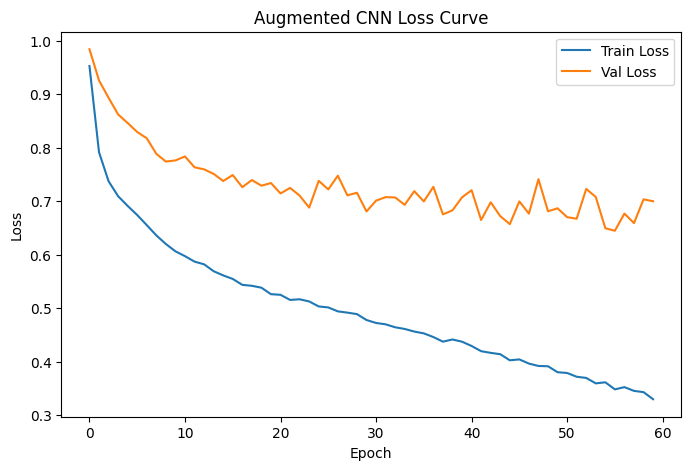

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_aug.history['loss'], label='Train Loss')
plt.plot(history_aug.history['val_loss'], label='Val Loss')
plt.title("Augmented CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


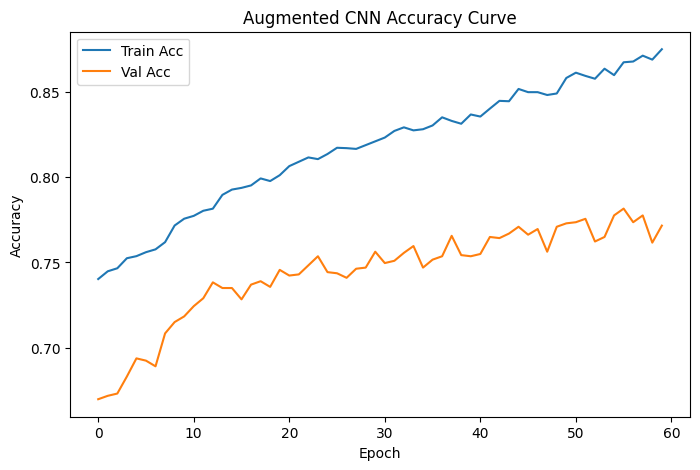

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_aug.history['accuracy'], label='Train Acc')
plt.plot(history_aug.history['val_accuracy'], label='Val Acc')
plt.title("Augmented CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [ ]:
y_pred_probs_aug = aug_cnn.predict(X_test)
y_pred_aug = np.argmax(y_pred_probs_aug, axis=1)
y_true_aug = np.argmax(y_test_cat, axis=1)


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


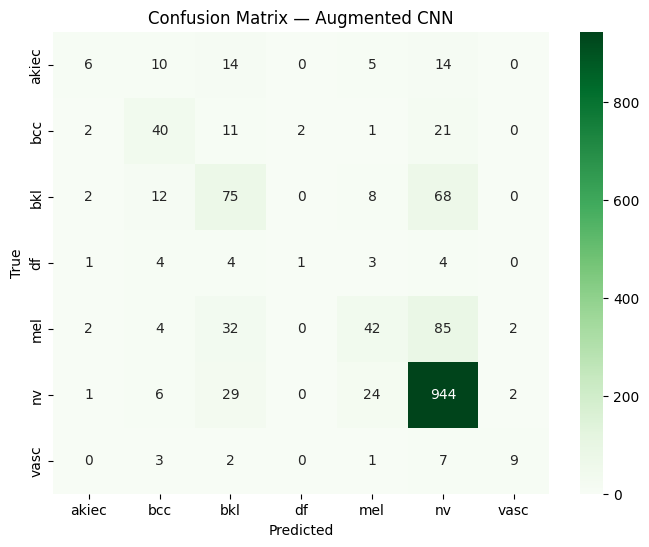

In [ ]:
cm_aug = confusion_matrix(y_true_aug, y_pred_aug)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_aug, annot=True, fmt="d",
    xticklabels=label_names,
    yticklabels=label_names,
    cmap="Greens"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Augmented CNN")
plt.show()


In [ ]:
print(classification_report(y_true_aug, y_pred_aug, target_names=label_names))

              precision    recall  f1-score   support

       akiec       0.43      0.12      0.19        49
         bcc       0.51      0.52      0.51        77
         bkl       0.45      0.45      0.45       165
          df       0.33      0.06      0.10        17
         mel       0.50      0.25      0.33       167
          nv       0.83      0.94      0.88      1006
        vasc       0.69      0.41      0.51        22

    accuracy                           0.74      1503
   macro avg       0.53      0.39      0.43      1503
weighted avg       0.71      0.74      0.72      1503

